# Checkpoint 5 · Quais commits revisar primeiro?
**Data Science & Statistical Computing — FIAP · 2026**

| Integrante | RM |
|---|---|
| Beatriz Cortêz Gomes | 561431 |
| Bruno Henrique Campos Alves | 563986 |
| Davi de Jesus Duarte | 566316 |
| Gabriel Augusto Gonçalves Pereira | 564126 |
| Raphaela Oliveira Tatto | 572059 |

## Resumo

- **Pergunta:** olhando para um commit, dá para saber se ele tem mais chance de introduzir um bug?
- **Para quê:** ajudar uma equipe a decidir quais commits revisar e testar primeiro. O modelo não encontra o bug e não substitui a revisão.
- **Dados:** 106.674 commits reais de 14 projetos Apache (base ApacheJIT). Cada commit tem uma marca: introduziu bug (1) ou não (0).
- **Pistas:** 48 informações de cada commit: tamanho, tipo de arquivo, mensagem, horário, experiência do autor e histórico dos arquivos alterados.
- **Modelos:** Random Forest, XGBoost e LightGBM, comparados nas mesmas condições e ajustados com Grid Search e Optuna.
- **Resultado e aplicativo:** Exercícios 6 e 7. O aplicativo Streamlit usa o mesmo modelo deste notebook.

**Como ler este notebook.** Cada exercício começa com uma explicação curta, mostra o código que foi executado e
termina com a leitura dos resultados. Os números dos textos de leitura são calculados na hora, a partir dos resultados.

**Aviso importante.** Este projeto teve uma primeira versão, que usava só o tamanho do commit. O período mais
recente dos dados, que serve de prova final, já tinha sido usado para avaliar aquela versão. Por isso o resultado
final daqui é uma **reavaliação**, não uma prova inédita. Todas as escolhas desta versão foram feitas sem olhar
esse período. As regras completas estão em `PROTOCOLO.md`.

**Como executar.** Instale as bibliotecas de `requirements.txt` e execute todas as células em ordem.
As buscas demoradas já foram feitas e estão salvas em `resultados/`; o notebook lê esses resultados.
No Exercício 6, as nove configurações são treinadas de novo para conferir os valores salvos (cerca de dois minutos).
As 48 pistas de cada commit acompanham o projeto em `artefatos/pistas_completas.parquet`, então não é preciso
baixar os repositórios para executar.

## Exercício 1 — Problema e base de dados

**Contexto.** Revisar código leva tempo. Se a equipe souber quais commits são mais arriscados, pode olhar esses primeiro.

**Tipo de problema.** Classificação binária. A variável-alvo `y` é a coluna `buggy`: 1 quando a base marca o commit
como introdutor de bug e 0 caso contrário. A previsão `ŷ` sai como um **score de risco entre 0 e 1**.
A partir de 0,5 o commit entra na lista de "revisar primeiro".

**Base.** [ApacheJIT v2](https://zenodo.org/records/5907847) (DOI 10.5281/zenodo.5907847), pública, licença CC BY 4.0.
Foi baixada do Zenodo e o arquivo foi conferido por checksum. Tem 106.674 linhas e 18 colunas; cada linha é um commit.
As pistas novas desta versão foram calculadas por nós a partir do histórico Git público dos mesmos projetos.

**Como um commit ganhou a marca de bug.** Os autores da base partiram de correções de bugs já registradas e voltaram
no histórico para achar o commit que escreveu as linhas corrigidas (método SZZ). O método erra às vezes, e um bug
que ainda não foi corrigido fica sem marca. Por isso a marca é um bom indício, não uma certeza.

**Critério de sucesso.** A métrica principal é o **F1 da classe 1**. Ele junta duas perguntas:
dos alertas do modelo, quantos eram bugs (*precision*)? Dos bugs, quantos o modelo alertou (*recall*)?
Não usamos a acurácia como métrica principal porque a maioria dos commits não tem bug: responder "sem bug"
sempre acerta bastante e não encontra nenhum. O modelo precisa superar essa resposta preguiçosa.

In [1]:
import inspect, json, platform, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
warnings.filterwarnings('ignore', message='IProgress not found')
from esquema import ROOT, FEATURES, GRUPOS, DESCRICOES
from dados import base_original, carregar_dividir
from treinamento import (preparar, baselines, comparacao, comparar_entradas, selecionar, diagnosticar,
                         faixas_de_risco, avaliar_final, construir, metricas, avaliar_cv, resumo_cv,
                         buscar_grid, sugerir, buscar_optuna, GRADES, MODELOS, slug)
from modelo import carregar_modelo, prever
from links import URL_GITHUB, URL_STREAMLIT
import graficos

pd.set_option('display.max_columns', 15)
pd.set_option('display.max_colwidth', 100)

def br(x, casas=3):
    """Número com vírgula decimal."""
    return f'{x:.{casas}f}'.replace('.', ',')

def pct(x, casas=1):
    return br(100 * x, casas) + '%'

def mil(x):
    """Inteiro com ponto de milhar."""
    return f'{int(x):,}'.replace(',', '.')

def texto(t):
    display(Markdown(t))

def mostrar_codigo(*funcoes):
    """Mostra o código executado, que fica nos módulos compartilhados com o aplicativo."""
    texto('\n\n'.join(f'```python\n{inspect.getsource(f)}```' for f in funcoes))

print('Python:', platform.python_version())
original = base_original()
display(original.drop(columns='data').head(3))
treino, teste, folds, divisao = preparar()
resumo = pd.Series({
    'Linhas e colunas da base original': f"{mil(divisao['dimensoes_originais'][0])} × {divisao['dimensoes_originais'][1]}",
    'Commits usados (treino + período final)': mil(len(treino) + len(teste)),
    'Commits excluídos na limpeza': divisao['n_excluidos'],
    'Commits de treino': mil(len(treino)),
    'Commits do período final': mil(len(teste)),
    'Início do período final (UTC)': divisao['inicio_teste'],
    'Commits com marca de bug no treino': pct(treino.buggy.mean()),
})
display(resumo.to_frame('Valor'))

Python: 3.13.3


,commit_id,project,buggy,fix,year,author_date,la,...,ent,ndev,age,nuc,aexp,arexp,asexp
0,a322a829a586cf03685152f06cc7025d66062202,apache/groovy,0,False,2003,1063292086,58,...,0.0,1.0,0.0,1.0,10,10.0,6.0
1,8169b159895f5f727287f6dff351e61569d03f48,apache/groovy,0,False,2003,1063292137,78,...,0.0,0.0,0.0,0.0,21,21.0,1.0
2,a93ff66772451264ef054ed19e98448d3f01953b,apache/groovy,0,False,2003,1063292285,2,...,0.0,2.0,0.0,2.0,11,11.0,7.0


,Valor
Linhas e colunas da base original,106.674 × 18
Commits usados (treino + período final),105.839
Commits excluídos na limpeza,835
Commits de treino,84.106
Commits do período final,21.733
Início do período final (UTC),2017-10-06 17:39:59+00:00
Commits com marca de bug no treino,"28,9%"


## Exercício 2 — Limpeza e exploração dos dados

**Em poucas palavras:** a base já veio limpa. Conferimos tudo e tiramos só os commits cujas pistas não dava para calcular direito.

- **O que conferimos:** tipos das colunas, valores ausentes, commits repetidos e números impossíveis (negativos, por exemplo). Nada disso apareceu nas 48 pistas.
- **Recontagem:** para cada commit, contamos de novo as linhas adicionadas, as removidas e os arquivos direto do Git. Só ficam os commits em que os três números são iguais aos da base.
- **O que saiu:** menos de 1% dos commits, quase todos por terem arquivos binários (uma imagem, por exemplo), em que não existe contagem de linhas. A exclusão não olha se o commit tem bug.
- **O que não fizemos:** não removemos commits grandes (eles são reais), não balanceamos as classes e não padronizamos os números, porque modelos de árvore não precisam disso.
- **Dentro do pipeline:** se faltar um valor, ele é preenchido com a mediana aprendida só nos dados de treino de cada rodada. Aqui não faltou nenhum.

A exploração usa **somente os dados de treino**. O período final fica guardado até o Exercício 7.

,tipo,valores ausentes
la,int64,0
ld,int64,0
nf,int64,0
o_n_java,int64,0
o_n_teste,int64,0
o_n_producao,int64,0
o_n_outros,int64,0
o_tem_teste,int64,0
o_frac_la_teste,float64,0
o_la_producao,int64,0


,count,mean,std,min,50%,95%,99%,max
la,84106.0,173.002295,490.128133,0.000000,36.000000,729.000000,2294.500000,9967.000000
ld,84106.0,71.795544,301.344614,0.000000,8.000000,286.000000,1127.950000,9950.000000
nf,84106.0,5.994091,9.524762,1.000000,3.000000,22.000000,52.000000,100.000000
o_n_java,84106.0,4.919673,8.247412,1.000000,2.000000,18.000000,44.000000,99.000000
o_n_teste,84106.0,1.851604,4.760581,0.000000,1.000000,7.000000,22.000000,96.000000
o_n_producao,84106.0,3.447947,6.146116,0.000000,1.000000,13.000000,31.000000,95.000000
o_n_outros,84106.0,1.074418,3.732206,0.000000,0.000000,4.000000,16.000000,97.000000
o_tem_teste,84106.0,0.556191,0.496835,0.000000,1.000000,1.000000,1.000000,1.000000
o_frac_la_teste,84106.0,0.317322,0.386845,0.000000,0.055556,1.000000,1.000000,1.000000
o_la_producao,84106.0,92.000892,304.197102,0.000000,13.000000,403.000000,1306.950000,9293.000000


,commits excluídos
motivo,
binario,768
binario;la_diverge_csv;ld_diverge_csv,34
binario;la_diverge_csv,26
binario;ld_diverge_csv,4
merge_ou_raiz,3


Commits repetidos no treino: 0
Tamanho final: treino (84106, 48) | período final (21733, 48)
Parte da base original que foi mantida: 99,22%


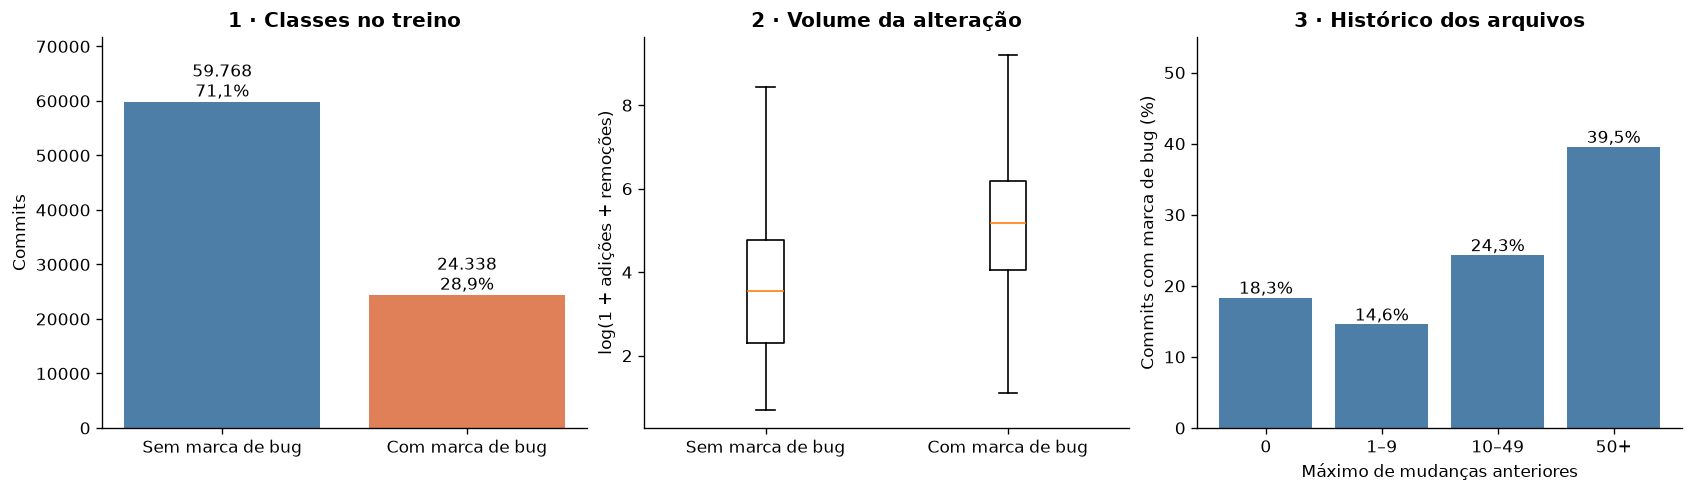

In [2]:
auditoria = json.loads((ROOT/'resultados/auditoria_treino.json').read_text(encoding='utf-8'))
display(pd.DataFrame({'tipo': auditoria['tipos'], 'valores ausentes': auditoria['ausencias']}))
display(treino[FEATURES].describe(percentiles=[.5, .95, .99]).T)
exclusoes = pd.read_csv(ROOT/'resultados/exclusoes.csv')
display(exclusoes.motivo.value_counts().rename('commits excluídos').to_frame())
print('Commits repetidos no treino:', auditoria['duplicatas_sha'])
print('Tamanho final: treino', treino[FEATURES].shape, '| período final', teste[FEATURES].shape)
print('Parte da base original que foi mantida:', pct((len(treino) + len(teste)) / len(original), 2))
display(graficos.explorar(treino)); plt.close('all')

**Leitura dos três gráficos acima**

1. **Classes.** Só 28,9% dos commits de treino têm marca de bug. Por isso acertar "no geral" é fácil e enganoso.
2. **Tamanho.** Commits com bug são maiores: metade deles altera mais de 175 linhas, contra 34 nos demais. Mas há muita mistura; tamanho sozinho não separa os dois grupos.
3. **Histórico do arquivo.** Quando o commit mexe em um arquivo que já foi alterado 50 vezes ou mais, 39,5% têm marca de bug. Em arquivos alterados de 1 a 9 vezes, 14,6%.

Os dois gráficos abaixo mostram o mesmo tipo de relação para duas pistas novas. Em todos os casos é uma
**associação**: arquivos muito alterados costumam ser os mais centrais e complexos. Os gráficos não provam
que alterar um arquivo cause bugs.

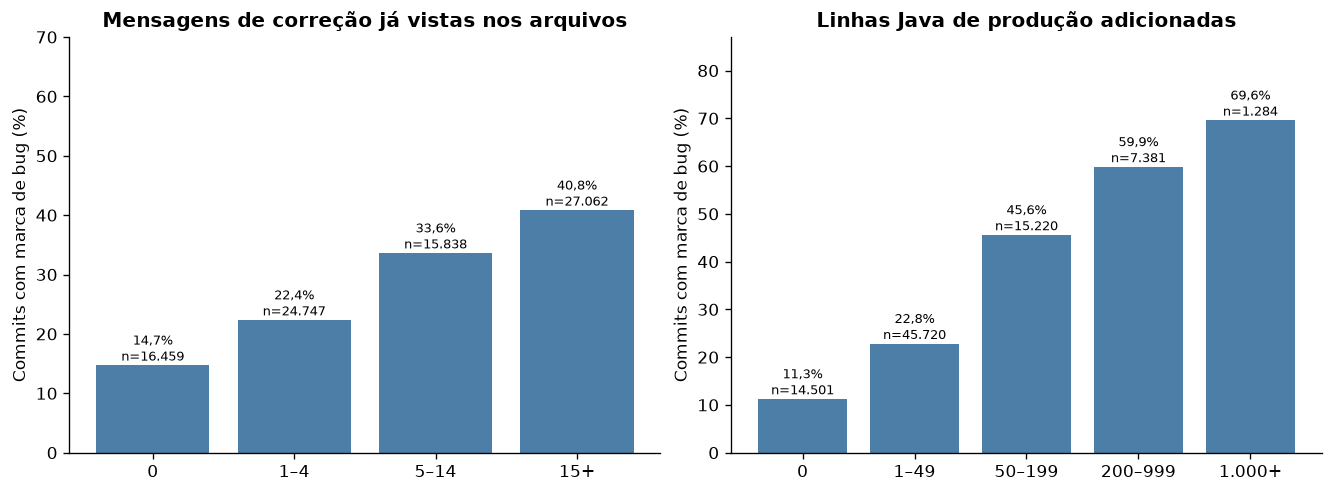

In [3]:
taxa = treino.buggy.mean()
medianas = (treino.la + treino.ld).groupby(treino.buggy).median()
mudancas = graficos.taxas(treino, 'l_arq_mudancas_max', [-1, 0, 9, 49, np.inf], ['0', '1–9', '10–49', '50+'])
texto(f'''**Leitura dos três gráficos acima**

1. **Classes.** Só {pct(taxa)} dos commits de treino têm marca de bug. Por isso acertar "no geral" é fácil e enganoso.
2. **Tamanho.** Commits com bug são maiores: metade deles altera mais de {medianas[1]:.0f} linhas, contra {medianas[0]:.0f} nos demais. Mas há muita mistura; tamanho sozinho não separa os dois grupos.
3. **Histórico do arquivo.** Quando o commit mexe em um arquivo que já foi alterado 50 vezes ou mais, {pct(mudancas.loc['50+', 'taxa'])} têm marca de bug. Em arquivos alterados de 1 a 9 vezes, {pct(mudancas.loc['1–9', 'taxa'])}.

Os dois gráficos abaixo mostram o mesmo tipo de relação para duas pistas novas. Em todos os casos é uma
**associação**: arquivos muito alterados costumam ser os mais centrais e complexos. Os gráficos não provam
que alterar um arquivo cause bugs.''')
display(graficos.historico(treino)); plt.close('all')

## Exercício 3 — Variáveis e desenho do experimento

**Em poucas palavras:** definimos o que o modelo pode ver, o que ele não pode ver e como testá-lo sem trapacear.

### O que o modelo vê (`X`): 48 pistas em seis grupos

| Grupo | Exemplos de pistas |
|---|---|
| Tamanho | linhas adicionadas, linhas removidas, arquivos alterados |
| Tipo da alteração | quantos arquivos são de teste, quantas linhas estão em código de produção |
| Momento | hora e dia da semana em que o commit foi escrito |
| Mensagem | tamanho da mensagem do commit |
| Autor | quantos commits a pessoa já tinha feito, se já tinha mexido nesses arquivos |
| Histórico dos arquivos | quantas vezes já foram alterados, por quantas pessoas, quantas mensagens antigas falavam em correção |

A lista completa aparece na tabela abaixo e em `esquema.py`. O alvo `y` é `buggy`.

### O que o modelo não vê, para evitar vazamento

Vazamento é dar ao modelo uma informação que entrega a resposta, ou que ele não teria na vida real.

- **Identificadores** (SHA, e-mail, nome do projeto). Não descrevem a alteração. Nesta base, o nome do projeto ainda está ligado ao modo como os commits com bug foram coletados.
- **Colunas `buggy` e `fix` de outros commits.** São respostas, não pistas.
- **Qualquer coisa do futuro.** O histórico de um commit conta apenas o que veio **antes** dele na linha principal do repositório. Commits posteriores e de outras branches não entram. Há testes automáticos só para isso em `testar_extracao.py`.
- **Palavras da mensagem do próprio commit**, como "fix". Ficaram de fora por cautela, porque a base foi montada a partir de correções. Testamos à parte e quase não muda o resultado (Exercício 5).

Um detalhe de vocabulário: "correções anteriores" de um arquivo significa mensagens antigas com palavras como
*fix* ou *bug*. É um indício de que o arquivo já deu trabalho, não um bug confirmado.

### Como o modelo é testado

- **Treino e período final.** Ordenamos os commits pela data em que entraram no repositório. Os anteriores a 06/10/2017 formam o treino; os mais recentes, o período final. Não sorteamos nem estratificamos: um sorteio deixaria o modelo aprender com o futuro para prever o passado.
- **Validação cruzada temporal, com 3 folds.** Dentro do treino fazemos três simulados. Em cada um, o modelo aprende com um trecho do passado e é avaliado no trecho seguinte. O trecho de aprendizado cresce a cada rodada.
- **Mesmas condições para todos.** Os três algoritmos usam as mesmas pistas, os mesmos três simulados e a mesma métrica. A semente aleatória é 42 em tudo, para o resultado ser reproduzível.

### Métricas

| Métrica | O que responde |
|---|---|
| **F1 da classe 1 (principal)** | Equilíbrio entre precision e recall, com alerta a partir de score 0,5 |
| Precision | Dos alertas, quantos eram bugs |
| Recall | Dos bugs, quantos foram alertados |
| Acurácia | Quantas respostas certas no total; engana quando bug é raro |
| ROC-AUC | Sorteando um commit com bug e um sem, quantas vezes o com bug recebe o score maior (0,5 é sorte, 1 é perfeito) |
| Average Precision | Qualidade da ordenação, olhando para os commits com bug |

In [4]:
display(pd.DataFrame([{'grupo': g, 'variável': f, 'significado': d} for g, fs in GRUPOS.items() for f, d in fs.items()]))
display(pd.read_csv(ROOT/'resultados/folds.csv'))
assert len(FEATURES) == 48
assert not set(treino.commit_id) & set(teste.commit_id)
for it, iv in folds:
    assert treino.iloc[it].data.max() < treino.iloc[iv].data.min()
print('Conferido: nenhum commit está no treino e no período final, e cada simulado avalia só datas posteriores ao seu treino.')
texto('**Código que carrega a base, junta as 48 pistas e faz a divisão por tempo** (`dados.py`):')
mostrar_codigo(carregar_dividir)

,grupo,variável,significado
0,Tamanho,la,Linhas adicionadas
1,Tamanho,ld,Linhas removidas
2,Tamanho,nf,Arquivos afetados
3,Tipo da alteração,o_n_java,Arquivos Java
4,Tipo da alteração,o_n_teste,Arquivos de teste
5,Tipo da alteração,o_n_producao,Arquivos Java fora de testes
6,Tipo da alteração,o_n_outros,Arquivos não Java
7,Tipo da alteração,o_tem_teste,Presença de teste
8,Tipo da alteração,o_frac_la_teste,Fração das adições em testes
9,Tipo da alteração,o_la_producao,Adições em Java de produção


,fold,n_treino,n_validacao,treino_inicio,treino_fim,validacao_inicio,validacao_fim
0,1,20166,20463,2003-09-11 14:54:46+00:00,2011-03-21 23:56:35+00:00,2011-03-22 00:22:04+00:00,2014-02-21 10:56:47+00:00
1,2,40629,21678,2003-09-11 14:54:46+00:00,2014-02-21 10:56:47+00:00,2014-02-21 11:26:01+00:00,2015-09-10 07:34:24+00:00
2,3,62307,21799,2003-09-11 14:54:46+00:00,2015-09-10 07:34:24+00:00,2015-09-10 07:42:01+00:00,2017-10-06 17:12:24+00:00


Conferido: nenhum commit está no treino e no período final, e cada simulado avalia só datas posteriores ao seu treino.


**Código que carrega a base, junta as 48 pistas e faz a divisão por tempo** (`dados.py`):

```python
def carregar_dividir():
    base=base_original()
    path=ROOT/"artefatos/pistas_completas.parquet"
    if not path.exists(): extrair_base()
    manifesto=json.loads((ROOT/"resultados/extracao.json").read_text(encoding="utf-8"))
    if manifesto["extrator_sha256"]!=hash_extrator():
        raise ValueError("Extrator alterado. Execute dados.py --extrair antes de treinar.")
    if hashlib.sha256(path.read_bytes()).hexdigest()!=manifesto["pistas_sha256"]:
        raise ValueError("Características diferentes do manifesto da extração.")
    pistas=pd.read_parquet(path)
    corte=base.iloc[int(len(base)*0.8)].data
    bruto_treino=base[base.data<corte].reset_index(drop=True)
    juntos=base.merge(pistas,on="commit_id",how="left",suffixes=("_csv",""),validate="one_to_one")
    if juntos.repositorio_git.isna().any(): raise ValueError("Cobertura incompleta da extração.")
    for f in ["la","ld","nf"]:
        diff=juntos[f]!=juntos[f+"_csv"]
        juntos.loc[diff,"motivo"] = juntos.loc[diff,"motivo"] + f";{f}_diverge_csv"
    diff=juntos.author_date!=juntos.author_date_git
    juntos.loc[diff,"motivo"]=juntos.loc[diff,"motivo"]+";data_diverge_csv"
    juntos['data_autoria']=juntos['data']
    juntos['data']=pd.to_datetime(juntos.committer_date_git,unit='s',utc=True)
    juntos=juntos.sort_values(['data','commit_id','project'],kind='stable').reset_index(drop=True)
    datas=np.sort(juntos.loc[juntos.data<corte,'committer_date_git'].unique())
    janelas=[(datas[a],datas[b]) for a,b in TimeSeriesSplit(n_splits=3).split(datas)]
    excluidos=juntos[juntos.motivo.ne("")]
    excluidos[["commit_id","project","data","motivo"]].to_csv(ROOT/"resultados/exclusoes.csv",index=False)
    elegiveis=juntos[juntos.motivo.eq("")].copy()
    treino=elegiveis[elegiveis.data<corte].reset_index(drop=True)
    teste=elegiveis[elegiveis.data>=corte].reset_index(drop=True)
    folds=[(np.flatnonzero(treino.committer_date_git.isin(a)),np.flatnonzero(treino.committer_date_git.isin(b))) for a,b in janelas]
    assert not set(treino.commit_id)&set(teste.commit_id)
    assert treino.data.max()<teste.data.min()
    for a,b in folds: assert treino.iloc[a].data.max()<treino.iloc[b].data.min()
    info={"dimensoes_originais":[len(base),18],"n_treino_original":int((juntos.data<corte).sum()),
          "n_teste_original":int((juntos.data>=corte).sum()),"n_treino":len(treino),"n_teste":len(teste),
          "ordenacao":"committer_date Git (integração)","n_treino_por_autoria_antes_filtro":len(bruto_treino),
          "autoria_antes_integracao_depois_corte":int(((juntos.data_autoria<corte)&(juntos.data>=corte)).sum()),
          "n_excluidos":len(excluidos),"inicio_teste":str(corte),"csv_sha256":CSV_SHA256,
          "extrator_sha256":hash_extrator(),"sha_compartilhados":0,
          "avaliacao_final":"Holdout já avaliado na versão inicial; reavaliação exploratória, não teste intocado."}
    return treino,teste,folds,info
```

## Exercício 4 — Três modelos de referência

**Em poucas palavras:** antes de ajustar qualquer coisa, treinamos os três algoritmos com configurações padrão para ter um ponto de partida.

Os três são feitos de **árvores de decisão**. Uma árvore é uma sequência de perguntas de sim ou não
("mais de 100 linhas?", "o arquivo já foi alterado mais de 50 vezes?") que termina em um risco.

- **Random Forest:** muitas árvores independentes, cada uma dá um palpite e elas votam.
- **XGBoost e LightGBM:** as árvores são construídas uma depois da outra, e cada nova árvore tenta corrigir os erros das anteriores (*boosting*).

Para comparação, incluímos dois modelos de mentira: o **Dummy**, que sempre responde "sem bug", e o
**Sempre positivo**, que alerta tudo. Um modelo útil precisa ser melhor que os dois.

Na tabela, "F1 treino" é a nota nos dados que o modelo estudou e "F1 validação" é a nota nos simulados.
"Gap" é a diferença entre as duas; "desvio" é o quanto a nota variou entre os três simulados.

In [5]:
texto('**Código que monta cada modelo, calcula as métricas e roda os três simulados** (`treinamento.py`):')
mostrar_codigo(construir, metricas, avaliar_cv)

**Código que monta cada modelo, calcula as métricas e roda os três simulados** (`treinamento.py`):

```python
def construir(nome, parametros=None):
    comuns = {"random_state": SEED, "n_jobs": N_JOBS, "n_estimators": 150}
    if nome == "Random Forest":
        params = {**comuns, "max_depth": None, "min_samples_leaf": 1, **(parametros or {})}
        modelo = RandomForestClassifier(**params)
    elif nome == "XGBoost":
        params = {**comuns, "max_depth": 6, "learning_rate": 0.1, "tree_method": "hist",
                  "objective": "binary:logistic", "eval_metric": "logloss", **(parametros or {})}
        modelo = XGBClassifier(**params)
    elif nome == "LightGBM":
        params = {**comuns, "num_leaves": 31, "learning_rate": 0.1, "verbosity": -1,
                  "deterministic": True, "force_col_wise": True, **(parametros or {})}
        modelo = LGBMClassifier(**params)
    elif nome == "Sempre positivo":
        modelo = DummyClassifier(strategy="constant", constant=1, random_state=SEED)
    else:
        modelo = DummyClassifier(strategy="most_frequent", random_state=SEED)
    imputer = SimpleImputer(strategy="median", keep_empty_features=True).set_output(transform="pandas")
    return Pipeline([("imputacao", imputer), ("modelo", modelo)])
```

```python
def metricas(y, p):
    pred = (np.asarray(p) >= LIMIAR).astype(int)
    return {"f1": f1_score(y, pred, zero_division=0),
            "precision": precision_score(y, pred, zero_division=0),
            "recall": recall_score(y, pred, zero_division=0),
            "acuracia": accuracy_score(y, pred), "roc_auc": roc_auc_score(y, p),
            "average_precision": average_precision_score(y, p)}
```

```python
def avaliar_cv(nome, params, treino, folds):
    inicio = perf_counter()
    scores = cross_validate(construir(nome, params), treino[FEATURES], treino.buggy,
                            cv=folds, scoring=pontuar, n_jobs=1, return_train_score=True,
                            error_score="raise")
    return scores, perf_counter() - inicio
```

In [6]:
base = pd.DataFrame(baselines(treino, folds))
colunas = ['modelo', 'estrategia', 'f1_treino', 'f1_validacao', 'desvio_f1', 'gap',
           'validacao_precision', 'validacao_recall', 'validacao_acuracia', 'validacao_roc_auc', 'tempo_s']
display(base[colunas].round(4))
display(pd.DataFrame([{'modelo': r['modelo'], 'hiperparâmetros': r['hiperparametros_completos']} for r in base.to_dict('records')]))
linha = base.set_index('modelo')
rf, xgb, lgbm, dummy, sempre = (linha.loc[n] for n in ['Random Forest', 'XGBoost', 'LightGBM', 'Dummy', 'Sempre positivo'])
texto(f'''**Leitura**

- **Os três aprendem alguma coisa.** F1 de validação: Random Forest {br(rf.f1_validacao)}, XGBoost {br(xgb.f1_validacao)}, LightGBM {br(lgbm.f1_validacao)}. O Dummy tem F1 {br(dummy.f1_validacao)} e alertar tudo dá {br(sempre.f1_validacao)}.
- **Sinal de sobreajuste (overfitting).** O Random Forest tira {br(rf.f1_treino)} no treino e {br(rf.f1_validacao)} na validação: ele decorou os dados de treino. XGBoost e LightGBM também vão melhor no treino (gaps de {br(xgb.gap)} e {br(lgbm.gap)}), em grau menor.
- **Por que não olhar só a acurácia.** O Dummy acerta {pct(dummy.validacao_acuracia)} das respostas sem encontrar nenhum bug. Os modelos chegam a cerca de {pct(lgbm.validacao_acuracia)}.
- **Custo.** O Random Forest levou {br(rf.tempo_s, 1)} s nos três simulados; XGBoost e LightGBM, {br(xgb.tempo_s, 1)} s e {br(lgbm.tempo_s, 1)} s.''')

,modelo,estrategia,f1_treino,f1_validacao,desvio_f1,gap,validacao_precision,validacao_recall,validacao_acuracia,validacao_roc_auc,tempo_s
0,Random Forest,Baseline,1.0000,0.5536,0.0485,0.4464,0.6464,0.4958,0.7623,0.7881,18.0155
1,XGBoost,Baseline,0.7337,0.5371,0.0657,0.1967,0.6490,0.4839,0.7574,0.7927,2.9026
2,LightGBM,Baseline,0.7223,0.5472,0.0587,0.1751,0.6491,0.4952,0.7600,0.7933,2.7195
3,Dummy,Baseline,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.6962,0.5000,0.4922
4,Sempre positivo,Baseline,0.4335,0.4652,0.0351,-0.0317,0.3038,1.0000,0.3038,0.5000,0.4825


,modelo,hiperparâmetros
0,Random Forest,"{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': No..."
1,XGBoost,"{'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsam..."
2,LightGBM,"{'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 1.0, 'importance_type': 'spl..."
3,Dummy,"{'constant': None, 'random_state': 42, 'strategy': 'most_frequent'}"
4,Sempre positivo,"{'constant': 1, 'random_state': 42, 'strategy': 'constant'}"


**Leitura**

- **Os três aprendem alguma coisa.** F1 de validação: Random Forest 0,554, XGBoost 0,537, LightGBM 0,547. O Dummy tem F1 0,000 e alertar tudo dá 0,465.
- **Sinal de sobreajuste (overfitting).** O Random Forest tira 1,000 no treino e 0,554 na validação: ele decorou os dados de treino. XGBoost e LightGBM também vão melhor no treino (gaps de 0,197 e 0,175), em grau menor.
- **Por que não olhar só a acurácia.** O Dummy acerta 69,6% das respostas sem encontrar nenhum bug. Os modelos chegam a cerca de 76,0%.
- **Custo.** O Random Forest levou 18,0 s nos três simulados; XGBoost e LightGBM, 2,9 s e 2,7 s.

## Exercício 5 — Ajuste com Grid Search e Optuna

**Em poucas palavras:** cada modelo tem "botões" (hiperparâmetros), como o número de árvores e a profundidade delas.
Testamos duas formas de escolher esses botões, sempre usando só os três simulados do treino.

**Grid Search** testa todas as combinações de um cardápio fixo. Aqui são 8 combinações por modelo:

| Modelo | Cardápio |
|---|---|
| Random Forest | árvores 150 ou 300; profundidade 8 ou sem limite; mínimo de commits por folha 1 ou 5 |
| XGBoost | árvores 150 ou 300; profundidade 3 ou 6; taxa de aprendizado 0,05 ou 0,1 |
| LightGBM | árvores 150 ou 300; folhas 15 ou 31; taxa de aprendizado 0,05 ou 0,1 |

**Optuna** não segue um cardápio. Ele testa uma configuração, olha a nota e usa isso para escolher a próxima.
Foram **20 tentativas (trials) por modelo**, com semente 42:

| Modelo | Onde o Optuna pode procurar |
|---|---|
| Todos | árvores de 150 a 300, de 50 em 50 |
| Random Forest | profundidade 8, 16 ou sem limite; mínimo por folha de 1 a 10; pistas por divisão: raiz quadrada ou todas |
| XGBoost | taxa de 0,03 a 0,2; profundidade de 2 a 6; `min_child_weight` de 1 a 10 |
| LightGBM | taxa de 0,03 a 0,2; folhas de 15 a 63; `min_child_samples` de 10 a 60 |

Nos dois casos, o objetivo é o maior F1 médio nos três simulados. O período final não participa.
Os tempos mostrados são os da execução original, não os de leitura dos resultados salvos.

In [7]:
print('Cardápios do Grid Search:', json.dumps(GRADES, ensure_ascii=False))
texto('**Código das duas buscas** (`treinamento.py`):')
mostrar_codigo(buscar_grid, sugerir, buscar_optuna)

Cardápios do Grid Search: {"Random Forest": {"n_estimators": [150, 300], "max_depth": [8, null], "min_samples_leaf": [1, 5]}, "XGBoost": {"n_estimators": [150, 300], "max_depth": [3, 6], "learning_rate": [0.05, 0.1]}, "LightGBM": {"n_estimators": [150, 300], "num_leaves": [15, 31], "learning_rate": [0.05, 0.1]}}


**Código das duas buscas** (`treinamento.py`):

```python
def buscar_grid(nome, treino, folds):
    path = RESULTADOS / f"grid_{slug(nome)}.json"
    if path.exists():
        return json.loads(path.read_text(encoding="utf-8"))
    print("Grid Search:", nome, "(8 combinações x 3 folds)", flush=True)
    busca = GridSearchCV(construir(nome), {f"modelo__{k}": v for k, v in GRADES[nome].items()},
                         scoring=pontuar, refit=False, cv=folds, n_jobs=1,
                         return_train_score=True, error_score="raise")
    inicio = perf_counter()
    busca.fit(treino[FEATURES], treino.buggy)
    tempo = perf_counter() - inicio
    tabela = pd.DataFrame(busca.cv_results_)
    tabela.to_csv(RESULTADOS / f"grid_{slug(nome)}_candidatos.csv", index=False)
    joblib.dump(busca.cv_results_, RESULTADOS / f"grid_{slug(nome)}_cv.joblib")
    melhor = int(tabela.mean_test_f1.argmax())
    params = {k.removeprefix("modelo__"): v for k, v in busca.cv_results_["params"][melhor].items()}
    scores = {f"{lado}_{metrica}": np.array([busca.cv_results_[f"split{k}_{lado}_{metrica}"][melhor]
               for k in range(3)]) for lado in ["train", "test"]
               for metrica in ["f1", "precision", "recall", "acuracia", "roc_auc", "average_precision"]}
    scores["fit_time"] = np.array([busca.cv_results_["mean_fit_time"][melhor]])
    linha = resumo_cv(nome, "Grid Search", params, scores, tempo)
    salvar_json(path, linha)
    return linha
```

```python
def sugerir(trial, nome):
    params = {"n_estimators": trial.suggest_int("n_estimators", 150, 300, step=50)}
    if nome == "Random Forest":
        params.update(max_depth=trial.suggest_categorical("max_depth", [8, 16, None]),
                      min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 10),
                      max_features=trial.suggest_categorical("max_features", ["sqrt", 1.0]))
    else:
        params["learning_rate"] = trial.suggest_float("learning_rate", 0.03, 0.2, log=True)
        if nome == "XGBoost":
            params.update(max_depth=trial.suggest_int("max_depth", 2, 6),
                          min_child_weight=trial.suggest_int("min_child_weight", 1, 10))
        else:
            params.update(num_leaves=trial.suggest_int("num_leaves", 15, 63),
                          min_child_samples=trial.suggest_int("min_child_samples", 10, 60))
    return params
```

```python
def buscar_optuna(nome, treino, folds):
    path = RESULTADOS / f"optuna_{slug(nome)}.json"
    if path.exists():
        return json.loads(path.read_text(encoding="utf-8"))
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    sampler_path = RESULTADOS / f"sampler_{slug(nome)}.joblib"
    sampler = joblib.load(sampler_path) if sampler_path.exists() else optuna.samplers.TPESampler(seed=SEED)
    estudo = optuna.create_study(study_name=slug(nome), direction="maximize", sampler=sampler,
                                 storage=f"sqlite:///{(RESULTADOS / 'optuna.sqlite3').as_posix()}",
                                 load_if_exists=True)
    # Trials interrompidos não contam para os 20 completos.
    for t in estudo.get_trials(deepcopy=False):
        if t.state == optuna.trial.TrialState.RUNNING:
            estudo.tell(t.number, state=optuna.trial.TrialState.FAIL)
    def objetivo(trial):
        params = sugerir(trial, nome)
        scores, tempo = avaliar_cv(nome, params, treino, folds)
        linha = resumo_cv(nome, "Optuna", params, scores, tempo)
        trial.set_user_attr("resultado", linha)
        return linha["f1_validacao"]
    def checkpoint(study, trial):
        joblib.dump(study.sampler, sampler_path)
        study.trials_dataframe().to_csv(RESULTADOS / f"optuna_{slug(nome)}_trials.csv", index=False)
        print(f"Optuna {nome}: trial {trial.number + 1}/20, F1={trial.value:.4f}", flush=True)
    completos = sum(t.state == optuna.trial.TrialState.COMPLETE for t in estudo.trials)
    estudo.optimize(objetivo, n_trials=max(0, 20 - completos), n_jobs=1, callbacks=[checkpoint])
    linha = dict(estudo.best_trial.user_attrs["resultado"])
    linha["tempo_melhor_trial_s"] = linha["tempo_s"]
    linha["tempo_s"] = sum(t.duration.total_seconds() for t in estudo.trials if t.duration)
    linha["trials_completos"] = sum(t.state == optuna.trial.TrialState.COMPLETE for t in estudo.trials)
    salvar_json(path, linha)
    return linha
```

**Random Forest — as 8 combinações do Grid Search e as 20 tentativas do Optuna**

,params,mean_test_f1,std_test_f1,mean_train_f1,mean_fit_time
4,"{'modelo__max_depth': None, 'modelo__min_samples_leaf': 1, 'modelo__n_estimators': 150}",0.553640,0.048513,1.000000,6.027939
5,"{'modelo__max_depth': None, 'modelo__min_samples_leaf': 1, 'modelo__n_estimators': 300}",0.551101,0.049562,1.000000,11.702702
7,"{'modelo__max_depth': None, 'modelo__min_samples_leaf': 5, 'modelo__n_estimators': 300}",0.550412,0.045811,0.842296,10.465465
6,"{'modelo__max_depth': None, 'modelo__min_samples_leaf': 5, 'modelo__n_estimators': 150}",0.550243,0.047428,0.841967,5.059278
3,"{'modelo__max_depth': 8, 'modelo__min_samples_leaf': 5, 'modelo__n_estimators': 300}",0.519633,0.046309,0.575644,6.098194
2,"{'modelo__max_depth': 8, 'modelo__min_samples_leaf': 5, 'modelo__n_estimators': 150}",0.518119,0.046874,0.573888,2.922681
1,"{'modelo__max_depth': 8, 'modelo__min_samples_leaf': 1, 'modelo__n_estimators': 300}",0.517709,0.047705,0.580888,5.741971
0,"{'modelo__max_depth': 8, 'modelo__min_samples_leaf': 1, 'modelo__n_estimators': 150}",0.512992,0.049063,0.579489,2.957781


,number,value,params_max_depth,params_max_features,params_min_samples_leaf,params_n_estimators,state
0,0,0.518594,8.0,sqrt,2,200,COMPLETE
1,1,0.545990,16.0,sqrt,10,300,COMPLETE
2,2,0.538601,NaN,1.0,5,150,COMPLETE
3,3,0.537040,NaN,1.0,8,150,COMPLETE
4,4,0.538877,16.0,1.0,1,250,COMPLETE
5,5,0.538839,NaN,1.0,5,300,COMPLETE
6,6,0.520774,8.0,1.0,4,150,COMPLETE
7,7,0.522150,8.0,1.0,9,150,COMPLETE
8,8,0.537498,NaN,1.0,4,150,COMPLETE
9,9,0.538293,16.0,1.0,9,200,COMPLETE


**XGBoost — as 8 combinações do Grid Search e as 20 tentativas do Optuna**

,params,mean_test_f1,std_test_f1,mean_train_f1,mean_fit_time
7,"{'modelo__learning_rate': 0.1, 'modelo__max_depth': 6, 'modelo__n_estimators': 300}",0.545841,0.062861,0.816189,1.380401
3,"{'modelo__learning_rate': 0.05, 'modelo__max_depth': 6, 'modelo__n_estimators': 300}",0.543754,0.065741,0.733941,1.422236
5,"{'modelo__learning_rate': 0.1, 'modelo__max_depth': 3, 'modelo__n_estimators': 300}",0.538383,0.067387,0.640190,0.687114
6,"{'modelo__learning_rate': 0.1, 'modelo__max_depth': 6, 'modelo__n_estimators': 150}",0.537063,0.065737,0.733720,0.817932
2,"{'modelo__learning_rate': 0.05, 'modelo__max_depth': 6, 'modelo__n_estimators': 150}",0.533686,0.065955,0.672826,0.858251
4,"{'modelo__learning_rate': 0.1, 'modelo__max_depth': 3, 'modelo__n_estimators': 150}",0.527945,0.069749,0.610759,0.465567
1,"{'modelo__learning_rate': 0.05, 'modelo__max_depth': 3, 'modelo__n_estimators': 300}",0.525807,0.071698,0.607524,0.699073
0,"{'modelo__learning_rate': 0.05, 'modelo__max_depth': 3, 'modelo__n_estimators': 150}",0.505968,0.072154,0.580904,0.465017


,number,value,params_learning_rate,params_max_depth,params_min_child_weight,params_n_estimators,state
0,0,0.551363,0.182147,5,6,200,COMPLETE
1,1,0.484963,0.040332,2,9,150,COMPLETE
2,2,0.530795,0.114950,2,10,250,COMPLETE
3,3,0.505041,0.044882,2,2,300,COMPLETE
4,4,0.537700,0.081184,4,3,200,COMPLETE
5,5,0.511256,0.039089,3,4,250,COMPLETE
6,6,0.532164,0.133056,2,6,200,COMPLETE
7,7,0.534431,0.032764,5,2,250,COMPLETE
8,8,0.547636,0.181517,6,9,150,COMPLETE
9,9,0.528568,0.036107,5,5,200,COMPLETE


**LightGBM — as 8 combinações do Grid Search e as 20 tentativas do Optuna**

,params,mean_test_f1,std_test_f1,mean_train_f1,mean_fit_time
3,"{'modelo__learning_rate': 0.05, 'modelo__n_estimators': 300, 'modelo__num_leaves': 31}",0.552632,0.057524,0.723143,1.057854
7,"{'modelo__learning_rate': 0.1, 'modelo__n_estimators': 300, 'modelo__num_leaves': 31}",0.549268,0.057732,0.804179,0.949908
6,"{'modelo__learning_rate': 0.1, 'modelo__n_estimators': 300, 'modelo__num_leaves': 15}",0.548986,0.058373,0.711495,0.799900
5,"{'modelo__learning_rate': 0.1, 'modelo__n_estimators': 150, 'modelo__num_leaves': 31}",0.547239,0.058699,0.722324,0.616554
1,"{'modelo__learning_rate': 0.05, 'modelo__n_estimators': 150, 'modelo__num_leaves': 31}",0.546790,0.059336,0.669526,0.716997
4,"{'modelo__learning_rate': 0.1, 'modelo__n_estimators': 150, 'modelo__num_leaves': 15}",0.545434,0.061117,0.660391,0.530515
2,"{'modelo__learning_rate': 0.05, 'modelo__n_estimators': 300, 'modelo__num_leaves': 15}",0.542035,0.062617,0.660862,0.867037
0,"{'modelo__learning_rate': 0.05, 'modelo__n_estimators': 150, 'modelo__num_leaves': 15}",0.535593,0.064781,0.626187,0.586218


,number,value,params_learning_rate,params_min_child_samples,params_n_estimators,params_num_leaves,state
0,0,0.552465,0.182147,40,200,50,COMPLETE
1,1,0.534423,0.040332,54,150,17,COMPLETE
2,2,0.555941,0.114950,59,250,16,COMPLETE
3,3,0.549979,0.044882,19,300,23,COMPLETE
4,4,0.553811,0.081184,24,200,36,COMPLETE
5,5,0.550027,0.039089,28,250,29,COMPLETE
6,6,0.555853,0.133056,36,200,24,COMPLETE
7,7,0.551431,0.032764,18,250,44,COMPLETE
8,8,0.544678,0.181517,51,150,62,COMPLETE
9,9,0.550167,0.036107,32,200,48,COMPLETE


,modelo,estrategia,parametros,f1_validacao,desvio_f1,tempo_s
3,Random Forest,Grid Search,"{'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 150}",0.5536,0.0485,168.9025
4,Random Forest,Optuna,"{'n_estimators': 300, 'max_depth': None, 'min_samples_leaf': 2, 'max_features': 'sqrt'}",0.5549,0.0476,1388.1760
5,XGBoost,Grid Search,"{'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 300}",0.5458,0.0629,23.3140
6,XGBoost,Optuna,"{'n_estimators': 200, 'learning_rate': 0.18214744423753768, 'max_depth': 5, 'min_child_weight': 6}",0.5514,0.0578,49.6072
7,LightGBM,Grid Search,"{'learning_rate': 0.05, 'n_estimators': 300, 'num_leaves': 31}",0.5526,0.0575,26.3139
8,LightGBM,Optuna,"{'n_estimators': 250, 'learning_rate': 0.07902978859187117, 'num_leaves': 27, 'min_child_samples...",0.5609,0.0515,73.3013


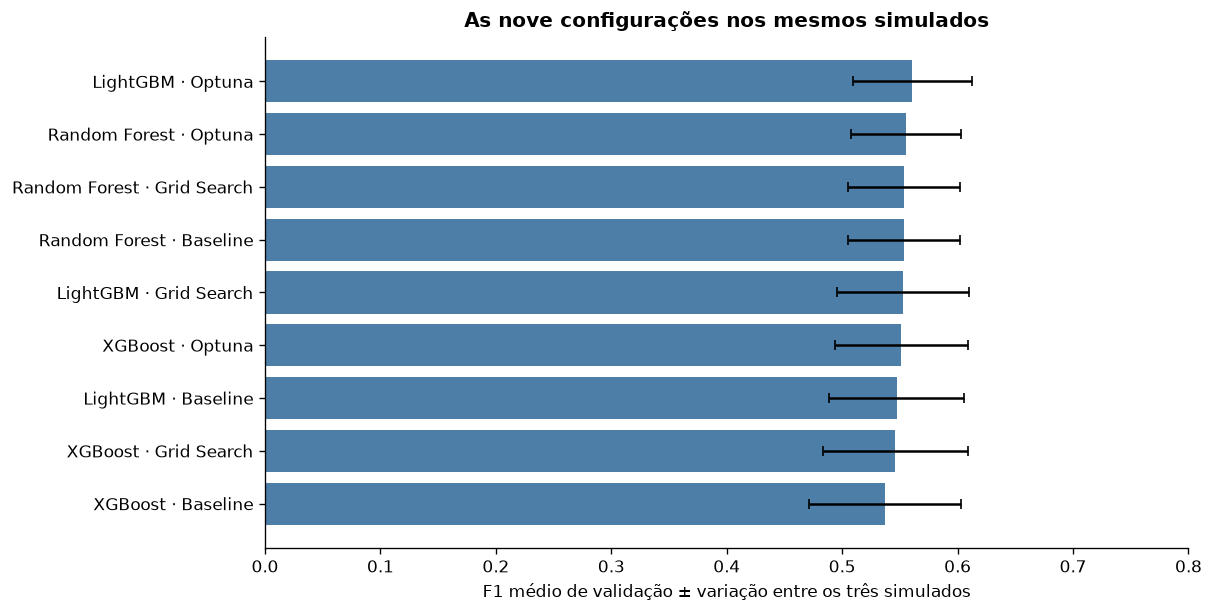

**Comparação das duas estratégias**

- **Random Forest:** Grid Search 0,5536 em 169 s; Optuna 0,5549 em 1388 s.
- **XGBoost:** Grid Search 0,5458 em 23 s; Optuna 0,5514 em 50 s.
- **LightGBM:** Grid Search 0,5526 em 26 s; Optuna 0,5609 em 73 s.

- **Qualidade.** O Optuna ficou à frente em 3 dos 3 modelos, mas por pouco: a maior diferença é de 0,0083 de F1. Isso é menor que a variação entre os três simulados, então não dá para dizer que uma estratégia é melhor que a outra.
- **Custo.** O Optuna demorou mais porque fez 20 tentativas contra 8 do Grid Search. No Random Forest a diferença de tempo é grande.
- **Comportamento.** O Grid Search só enxerga os valores do cardápio. O Optuna pode testar valores intermediários e se concentra nas regiões que deram nota melhor.
- **Cuidado.** Quanto mais tentativas, maior o risco de escolher uma configuração que só deu sorte nesses três simulados. Por isso existe um período final guardado.

In [8]:
tabela = comparacao(treino, folds)
for nome in MODELOS:
    texto(f'**{nome} — as 8 combinações do Grid Search e as 20 tentativas do Optuna**')
    grid = pd.read_csv(ROOT/f'resultados/grid_{slug(nome)}_candidatos.csv')
    display(grid[['params', 'mean_test_f1', 'std_test_f1', 'mean_train_f1', 'mean_fit_time']].sort_values('mean_test_f1', ascending=False))
    trials = pd.read_csv(ROOT/f'resultados/optuna_{slug(nome)}_trials.csv')
    assert trials.state.eq('COMPLETE').sum() == 20
    display(trials[[c for c in trials if c in ['number', 'value', 'state'] or c.startswith('params_')]])
buscas = tabela[tabela.estrategia.ne('Baseline')]
display(buscas[['modelo', 'estrategia', 'parametros', 'f1_validacao', 'desvio_f1', 'tempo_s']].round(4))
display(graficos.comparar(tabela)); plt.close('all')
frases = []
for nome in MODELOS:
    g = tabela[(tabela.modelo == nome) & (tabela.estrategia == 'Grid Search')].iloc[0]
    o = tabela[(tabela.modelo == nome) & (tabela.estrategia == 'Optuna')].iloc[0]
    frases.append(f'- **{nome}:** Grid Search {br(g.f1_validacao, 4)} em {br(g.tempo_s, 0)} s; Optuna {br(o.f1_validacao, 4)} em {br(o.tempo_s, 0)} s.')
diferencas = tabela[tabela.estrategia == 'Optuna'].f1_validacao.values - tabela[tabela.estrategia == 'Grid Search'].f1_validacao.values
ganho = diferencas.max()
texto('**Comparação das duas estratégias**\n\n' + '\n'.join(frases) + f'''

- **Qualidade.** O Optuna ficou à frente em {int((diferencas > 0).sum())} dos 3 modelos, mas por pouco: a maior diferença é de {br(ganho, 4)} de F1. Isso é menor que a variação entre os três simulados, então não dá para dizer que uma estratégia é melhor que a outra.
- **Custo.** O Optuna demorou mais porque fez 20 tentativas contra 8 do Grid Search. No Random Forest a diferença de tempo é grande.
- **Comportamento.** O Grid Search só enxerga os valores do cardápio. O Optuna pode testar valores intermediários e se concentra nas regiões que deram nota melhor.
- **Cuidado.** Quanto mais tentativas, maior o risco de escolher uma configuração que só deu sorte nesses três simulados. Por isso existe um período final guardado.''')

### As pistas novas ajudaram?

Para responder, mantemos o mesmo modelo e mudamos só as pistas. A primeira linha da tabela é a configuração
da primeira versão do projeto (só tamanho), avaliada nos mesmos commits e nos mesmos simulados.
As outras linhas usam um XGBoost de configuração fixa, para a comparação não depender do ajuste.
A última linha acrescenta as palavras da mensagem do próprio commit, só para medir o efeito; elas não entram no modelo final.

In [9]:
pistas = comparar_entradas(treino, folds)
display(pistas[['estrategia', 'n_entradas', 'f1_validacao', 'desvio_f1', 'validacao_precision', 'validacao_recall', 'validacao_acuracia', 'validacao_roc_auc']].round(4))
antigo, leve, completo, palavras = (pistas.iloc[i] for i in [0, 2, 3, 4])
texto(f'''**Leitura**

- Só com o tamanho, o F1 de validação é {br(antigo.f1_validacao)}.
- Somando tipo de arquivo e tamanho da mensagem, quase não muda: {br(leve.f1_validacao)}.
- Com o histórico de autores e arquivos, sobe para {br(completo.f1_validacao)}. O ganho vem do histórico. O ROC-AUC vai de {br(antigo.validacao_roc_auc)} para {br(completo.validacao_roc_auc)}.
- As palavras da mensagem do próprio commit acrescentam só {br(palavras.f1_validacao - completo.f1_validacao)}. Deixá-las de fora custa pouco.

Essa comparação foi feita depois de já conhecermos a base, então mostra uma melhora, não um limite máximo.''')

,estrategia,n_entradas,f1_validacao,desvio_f1,validacao_precision,validacao_recall,validacao_acuracia,validacao_roc_auc
0,Modelo inicial — mesma cobertura,3,0.4703,0.0728,0.6353,0.3844,0.7438,0.7721
1,Tamanho — configuração fixa,3,0.4619,0.0718,0.6282,0.3750,0.7411,0.7693
2,Tamanho + tipo + mensagem,21,0.4735,0.0708,0.6865,0.3773,0.7539,0.7825
3,Completo — ancestral,48,0.5509,0.0600,0.6527,0.5001,0.7615,0.7999
4,Completo + palavras atuais — sensibilidade,56,0.5528,0.0626,0.6537,0.5036,0.7622,0.8026


**Leitura**

- Só com o tamanho, o F1 de validação é 0,470.
- Somando tipo de arquivo e tamanho da mensagem, quase não muda: 0,474.
- Com o histórico de autores e arquivos, sobe para 0,551. O ganho vem do histórico. O ROC-AUC vai de 0,772 para 0,800.
- As palavras da mensagem do próprio commit acrescentam só 0,002. Deixá-las de fora custa pouco.

Essa comparação foi feita depois de já conhecermos a base, então mostra uma melhora, não um limite máximo.

## Exercício 6 — Escolha do modelo, sobreajuste e subajuste

**Em poucas palavras:** escolhemos uma das nove configurações usando só as notas dos simulados, e depois
olhamos se o modelo escolhido está decorando (sobreajuste) ou se falta informação (subajuste).

**Regra de escolha, definida antes de comparar:**

1. Ficam as configurações com F1 de validação a até 0,005 da melhor.
2. Entre elas, vence a de menor variação entre os simulados; depois a de menor gap; depois a de menos árvores; depois a mais rápida.

A ideia é não escolher um modelo só por um número um pouco maior: estabilidade e simplicidade também contam.
O período final não participa da escolha.

In [10]:
texto('**Código da escolha e dos diagnósticos** (`treinamento.py`):')
mostrar_codigo(selecionar, diagnosticar)

**Código da escolha e dos diagnósticos** (`treinamento.py`):

```python
def selecionar(tabela):
    proximos = tabela[tabela.f1_validacao >= tabela.f1_validacao.max() - 0.005].copy()
    proximos["gap_positivo"] = proximos.gap.clip(lower=0)
    proximos["arvores"] = proximos.parametros.map(lambda p: p.get("n_estimators", 150))
    vencedor = proximos.sort_values(["desvio_f1", "gap_positivo", "arvores", "ajuste_medio_s"],
                                    kind="stable").iloc[0]
    config = {"modelo": vencedor.modelo, "estrategia": vencedor.estrategia,
              "parametros": vencedor.parametros, "variaveis": FEATURES, "limiar": LIMIAR,
              "f1_validacao": vencedor.f1_validacao, "desvio_f1": vencedor.desvio_f1,
              "gap": vencedor.gap, "regra": "Tolerância 0,005; desvio, gap positivo, árvores e tempo."}
    salvar_json(RESULTADOS / "selecao.json", config)
    return config
```

```python
def diagnosticar(config, treino, folds):
    path = RESULTADOS / "diagnosticos.json"
    if path.exists():
        return json.loads(path.read_text(encoding="utf-8"))
    previsoes, aprendizado, importancias = [], [], []
    for k, (it, iv) in enumerate(folds, 1):
        for fracao in [0.25, 0.5, 1.0]:
            # Prefixos crescentes do passado; toda validação permanece posterior.
            indices = it[:max(2, int(len(it) * fracao))]
            modelo = construir(config["modelo"], config["parametros"])
            modelo.fit(treino.iloc[indices][FEATURES], treino.iloc[indices].buggy)
            p_train = modelo.predict_proba(treino.iloc[indices][FEATURES])[:, 1].astype(float)
            p_val = modelo.predict_proba(treino.iloc[iv][FEATURES])[:, 1].astype(float)
            aprendizado.append({"fold": k, "fracao": fracao, "n_treino": len(indices),
                                "f1_treino": metricas(treino.iloc[indices].buggy, p_train)["f1"],
                                "f1_validacao": metricas(treino.iloc[iv].buggy, p_val)["f1"]})
            if fracao == 1:
                previsoes.append(treino.iloc[iv][["commit_id", "buggy"]].assign(
                    fold=k, score=p_val, previsao=(p_val >= LIMIAR).astype(int)))
                imp = modelo.named_steps["modelo"].feature_importances_.astype(float)
                importancias.append(imp / imp.sum())
    oof = pd.concat(previsoes)
    assert not oof.commit_id.duplicated().any()
    oof.to_csv(RESULTADOS / "previsoes_validacao.csv", index=False)
    pd.DataFrame(aprendizado).to_csv(RESULTADOS / "curva_aprendizado.csv", index=False)
    pd.DataFrame({"variavel": FEATURES, "importancia": np.mean(importancias, axis=0)}).to_csv(
        RESULTADOS / "importancia.csv", index=False)
    resumo = {"metricas_validacao_agregada": metricas(oof.buggy, oof.score),
              "matriz_validacao": confusion_matrix(oof.buggy, oof.previsao, labels=[0, 1]).tolist(),
              "n_validacao": len(oof), "n_sem_previsao": len(treino) - len(oof)}
    salvar_json(path, resumo)
    return resumo
```

In [11]:
nove = ['modelo', 'estrategia', 'f1_treino', 'f1_validacao', 'desvio_f1', 'gap', 'tempo_s']
display(tabela[nove].round(4))
config = selecionar(tabela)
diag = diagnosticar(config, treino, folds)
display(pd.Series(config).drop('variaveis').to_frame('Configuração escolhida'))
proximas = tabela[tabela.f1_validacao >= tabela.f1_validacao.max() - 0.005]
texto(f'''**Escolhido: {config['modelo']} com {config['estrategia']}.** F1 médio de validação {br(config['f1_validacao'], 4)}, com variação de {br(config['desvio_f1'], 4)} entre os simulados e gap de {br(config['gap'], 4)}.
{'Só essa configuração ficou a até 0,005 do melhor F1.' if len(proximas) == 1 else f'{len(proximas)} configurações ficaram a até 0,005 do melhor F1; a regra de desempate escolheu esta.'}
As diferenças entre as nove configurações são pequenas perto da variação entre os simulados, então não afirmamos que um algoritmo é melhor que os outros de forma definitiva.''')

,modelo,estrategia,f1_treino,f1_validacao,desvio_f1,gap,tempo_s
0,Random Forest,Baseline,1.0000,0.5536,0.0485,0.4464,18.0155
1,XGBoost,Baseline,0.7337,0.5371,0.0657,0.1967,2.9026
2,LightGBM,Baseline,0.7223,0.5472,0.0587,0.1751,2.7195
3,Random Forest,Grid Search,1.0000,0.5536,0.0485,0.4464,168.9025
4,Random Forest,Optuna,0.9803,0.5549,0.0476,0.4254,1388.1760
5,XGBoost,Grid Search,0.8162,0.5458,0.0629,0.2703,23.3140
6,XGBoost,Optuna,0.7522,0.5514,0.0578,0.2008,49.6072
7,LightGBM,Grid Search,0.7231,0.5526,0.0575,0.1705,26.3139
8,LightGBM,Optuna,0.7320,0.5609,0.0515,0.1711,73.3013


,Configuração escolhida
modelo,LightGBM
estrategia,Optuna
parametros,"{'n_estimators': 250, 'learning_rate': 0.07902978859187117, 'num_leaves': 27, 'min_child_samples..."
limiar,0.5
f1_validacao,0.560901
desvio_f1,0.051524
gap,0.171134
regra,"Tolerância 0,005; desvio, gap positivo, árvores e tempo."


**Escolhido: LightGBM com Optuna.** F1 médio de validação 0,5609, com variação de 0,0515 entre os simulados e gap de 0,1711.
Só essa configuração ficou a até 0,005 do melhor F1.
As diferenças entre as nove configurações são pequenas perto da variação entre os simulados, então não afirmamos que um algoritmo é melhor que os outros de forma definitiva.

**Conferência ao vivo.** A tabela acima vem dos resultados salvos. A célula abaixo treina de novo, agora,
as nove configurações nos três simulados (27 treinos, sem tocar no período final) e compara o F1 com o valor salvo.
No computador da entrega a diferença é zero. Em outra máquina podem aparecer diferenças pequenas.

In [12]:
conferencia = []
for linha in tabela.itertuples():
    pontos, _ = avaliar_cv(linha.modelo, linha.parametros, treino, folds)
    agora = resumo_cv(linha.modelo, linha.estrategia, linha.parametros, pontos, 0)
    conferencia.append({'modelo': linha.modelo, 'estrategia': linha.estrategia, 'f1_validacao_salvo': linha.f1_validacao,
                        'f1_validacao_agora': agora['f1_validacao'], 'diferenca': abs(agora['f1_validacao'] - linha.f1_validacao)})
display(pd.DataFrame(conferencia))

,modelo,estrategia,f1_validacao_salvo,f1_validacao_agora,diferenca
0,Random Forest,Baseline,0.553640,0.553640,0.0
1,XGBoost,Baseline,0.537063,0.537063,0.0
2,LightGBM,Baseline,0.547239,0.547239,0.0
3,Random Forest,Grid Search,0.553640,0.553640,0.0
4,Random Forest,Optuna,0.554939,0.554939,0.0
5,XGBoost,Grid Search,0.545841,0.545841,0.0
6,XGBoost,Optuna,0.551363,0.551363,0.0
7,LightGBM,Grid Search,0.552632,0.552632,0.0
8,LightGBM,Optuna,0.560901,0.560901,0.0


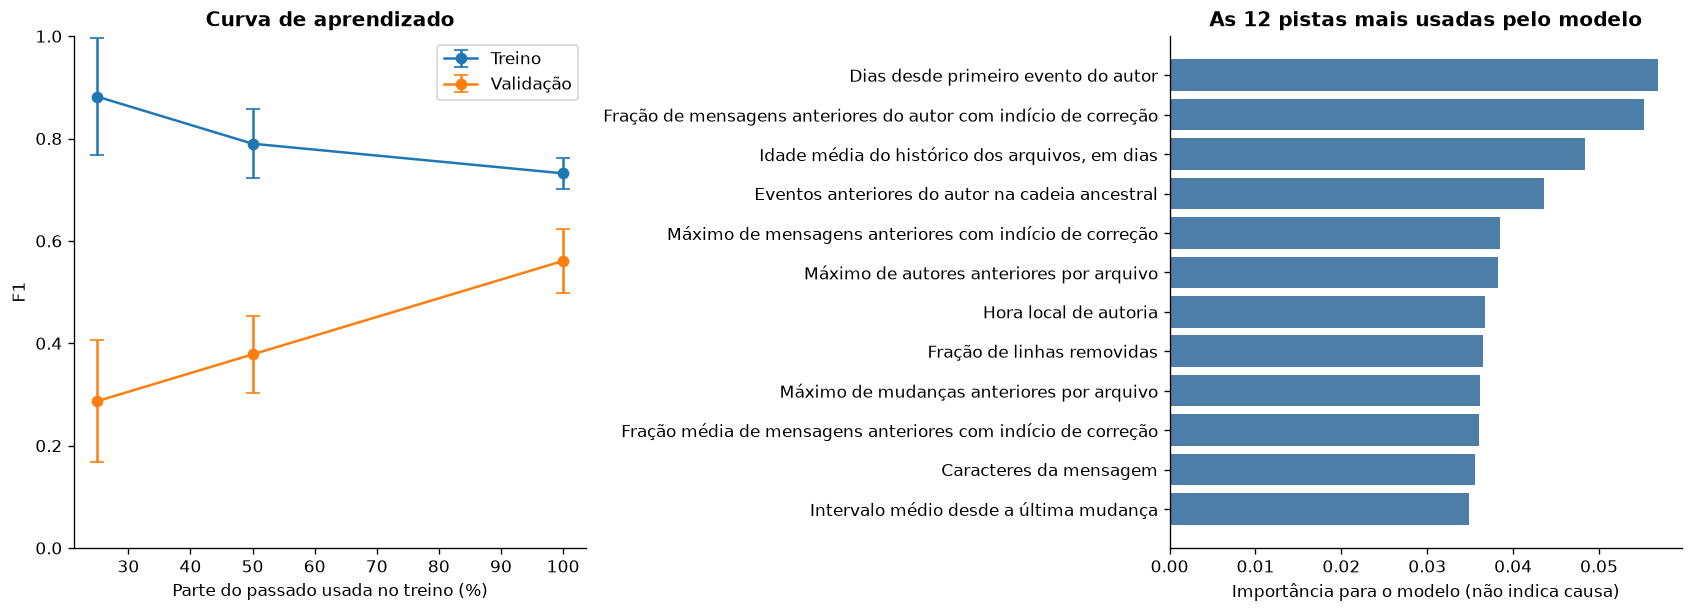

,fold,fracao,n_treino,f1_treino,f1_validacao
0,1,0.25,5041,0.9992,0.1881
1,1,0.50,10083,0.8660,0.3060
2,1,1.00,20166,0.7656,0.5132
3,2,0.25,10157,0.8742,0.2546
4,2,0.50,20314,0.7648,0.3737
5,2,1.00,40629,0.7249,0.5370
6,3,0.25,15576,0.7724,0.4183
7,3,0.50,31153,0.7390,0.4552
8,3,1.00,62307,0.7056,0.6325


**Sobreajuste ou subajuste?**

- **Sobreajuste (overfitting)** é decorar o treino. O Random Forest inicial é o exemplo claro: 1,000 no treino e 0,554 na validação.
- **O modelo escolhido ainda tem um pouco disso:** gap de 0,171 entre treino e validação. É bem menor que o do Random Forest, mas não é zero.
- **Subajuste (underfitting)** é não ter informação ou capacidade para ir bem nem no treino. Não é o caso principal aqui. Mesmo assim, o F1 de validação em torno de 0,56 mostra que as 48 pistas ainda não bastam para separar bem os commits, e parte disso vem de marcas de bug imperfeitas.

**Curva de aprendizado (gráfico da esquerda).** Em cada simulado, treinamos com 25%, 50% e 100% do passado disponível.
Com pouco passado, o modelo decora (F1 de treino 0,882) e vai mal no futuro (0,287).
Com todo o passado, o treino cai para 0,732 e a validação sobe para 0,561: a distância diminui.
Um cuidado: ao aumentar o trecho entram mais dados e também dados mais recentes, então a curva não separa os dois efeitos.

**Importância das variáveis (gráfico da direita).** As cinco pistas mais usadas pelo modelo foram:
dias desde primeiro evento do autor; fração de mensagens anteriores do autor com indício de correção; idade média do histórico dos arquivos, em dias; eventos anteriores do autor na cadeia ancestral; máximo de mensagens anteriores com indício de correção.
Pistas de autor e de histórico dos arquivos aparecem no topo, o que combina com o ganho visto no Exercício 5.
A importância mostra o que o modelo usou, não o que causa bugs. No LightGBM ela conta quantas vezes a pista foi usada nas árvores.

In [13]:
display(graficos.diagnosticos()); plt.close('all')
curva = pd.read_csv(ROOT/'resultados/curva_aprendizado.csv')
display(curva.round(4))
media = curva.groupby('fracao')[['f1_treino', 'f1_validacao']].mean()
rf = tabela[(tabela.modelo == 'Random Forest') & (tabela.estrategia == 'Baseline')].iloc[0]
importancia = pd.read_csv(ROOT/'resultados/importancia.csv').nlargest(5, 'importancia')
texto(f'''**Sobreajuste ou subajuste?**

- **Sobreajuste (overfitting)** é decorar o treino. O Random Forest inicial é o exemplo claro: {br(rf.f1_treino)} no treino e {br(rf.f1_validacao)} na validação.
- **O modelo escolhido ainda tem um pouco disso:** gap de {br(config['gap'])} entre treino e validação. É bem menor que o do Random Forest, mas não é zero.
- **Subajuste (underfitting)** é não ter informação ou capacidade para ir bem nem no treino. Não é o caso principal aqui. Mesmo assim, o F1 de validação em torno de {br(config['f1_validacao'], 2)} mostra que as 48 pistas ainda não bastam para separar bem os commits, e parte disso vem de marcas de bug imperfeitas.

**Curva de aprendizado (gráfico da esquerda).** Em cada simulado, treinamos com 25%, 50% e 100% do passado disponível.
Com pouco passado, o modelo decora (F1 de treino {br(media.loc[0.25, 'f1_treino'])}) e vai mal no futuro ({br(media.loc[0.25, 'f1_validacao'])}).
Com todo o passado, o treino cai para {br(media.loc[1.0, 'f1_treino'])} e a validação sobe para {br(media.loc[1.0, 'f1_validacao'])}: a distância diminui.
Um cuidado: ao aumentar o trecho entram mais dados e também dados mais recentes, então a curva não separa os dois efeitos.

**Importância das variáveis (gráfico da direita).** As cinco pistas mais usadas pelo modelo foram:
{'; '.join(DESCRICOES[v].lower() for v in importancia.variavel)}.
Pistas de autor e de histórico dos arquivos aparecem no topo, o que combina com o ganho visto no Exercício 5.
A importância mostra o que o modelo usou, não o que causa bugs. No LightGBM ela conta quantas vezes a pista foi usada nas árvores.''')

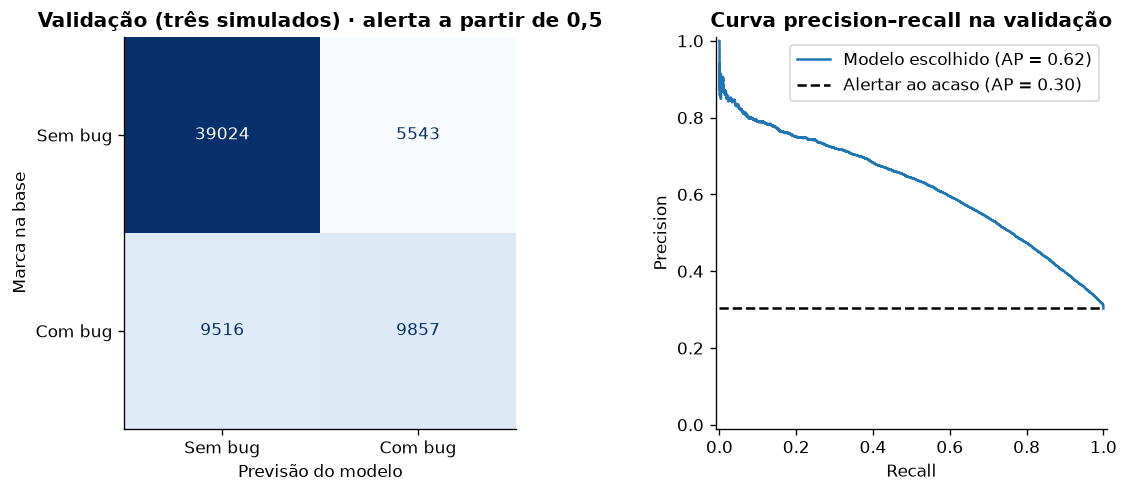

,Validação: os três simulados juntos
f1,0.566934
precision,0.640065
recall,0.508801
acuracia,0.764482
roc_auc,0.785743
average_precision,0.619574


,faixa,score_minimo,commits,taxa_buggy,taxa_geral
0,Baixo,0.0,33597,0.132065,0.302987
1,Moderado,0.2,14943,0.339892,0.302987
2,Alto,0.5,6524,0.540466,0.302987
3,Muito alto,0.7,8876,0.713272,0.302987


**Desempenho na validação** (os três simulados juntos; o primeiro trecho do treino não tem previsão porque nunca foi avaliado)

- **Matriz de confusão.** O modelo alertou 15.400 commits. Desses, 9.857 tinham marca de bug e 5.543 eram alarmes falsos. Ficaram sem alerta 9.516 commits com bug.
- Em palavras: 64,0% dos alertas estavam certos (precision) e 50,9% dos bugs foram alertados (recall).
- **Curva precision–recall.** Mostra a troca: para pegar mais bugs é preciso aceitar mais alarmes falsos. A linha tracejada é o que se conseguiria alertando ao acaso.
- **Faixas de risco (última tabela).** Agrupando os commits pelo score, 13,2% dos commits da faixa mais baixa tinham bug, contra 71,3% na mais alta. A média geral é 30,3%. O aplicativo mostra essa faixa junto do score.

In [14]:
display(graficos.validacao()); plt.close('all')
v = diag['metricas_validacao_agregada']
(tn, fp), (fn, tp) = diag['matriz_validacao']
display(pd.Series(v).to_frame('Validação: os três simulados juntos'))
faixas = faixas_de_risco()
display(faixas)
texto(f'''**Desempenho na validação** (os três simulados juntos; o primeiro trecho do treino não tem previsão porque nunca foi avaliado)

- **Matriz de confusão.** O modelo alertou {mil(tp + fp)} commits. Desses, {mil(tp)} tinham marca de bug e {mil(fp)} eram alarmes falsos. Ficaram sem alerta {mil(fn)} commits com bug.
- Em palavras: {pct(v['precision'])} dos alertas estavam certos (precision) e {pct(v['recall'])} dos bugs foram alertados (recall).
- **Curva precision–recall.** Mostra a troca: para pegar mais bugs é preciso aceitar mais alarmes falsos. A linha tracejada é o que se conseguiria alertando ao acaso.
- **Faixas de risco (última tabela).** Agrupando os commits pelo score, {pct(faixas.taxa_buggy.iloc[0])} dos commits da faixa mais baixa tinham bug, contra {pct(faixas.taxa_buggy.iloc[-1])} na mais alta. A média geral é {pct(faixas.taxa_geral.iloc[0])}. O aplicativo mostra essa faixa junto do score.''')

## Exercício 7 — Avaliação final, exemplos, aplicativo e links

**Em poucas palavras:** com a configuração já escolhida, treinamos o modelo em todo o treino, salvamos e medimos
o desempenho no período mais recente. Esse mesmo modelo salvo é o que o aplicativo usa.

**Lembrete.** O período final já tinha sido usado para avaliar a primeira versão do projeto. Por isso os números
abaixo são uma reavaliação. A configuração foi escolhida antes de calculá-los e não foi mudada depois.
Uma confirmação de verdade pede dados novos, de preferência de projetos fora da Apache.

In [15]:
texto('**Código da avaliação final e da função de previsão usada pelo aplicativo** (`treinamento.py` e `modelo.py`):')
mostrar_codigo(avaliar_final, prever)

**Código da avaliação final e da função de previsão usada pelo aplicativo** (`treinamento.py` e `modelo.py`):

```python
def avaliar_final(config, treino, teste, info):
    path = RESULTADOS / "teste_final.json"
    if path.exists():
        return json.loads(path.read_text(encoding="utf-8"))
    print("Configuração congelada. Reavaliação exploratória do holdout conhecido, uma vez nesta versão.", flush=True)
    pipeline = construir(config["modelo"], config["parametros"])
    pipeline.fit(treino[FEATURES], treino.buggy)
    # A mesma função de inferência será chamada pelo app.
    pred = prever(pipeline, teste[FEATURES])
    resumo = {"metricas": metricas(teste.buggy, pred.score),
              "referencia_majoritaria": metricas(teste.buggy, np.full(len(teste), int(treino.buggy.mode()[0]))),
              "matriz_confusao": confusion_matrix(teste.buggy, pred.previsao, labels=[0, 1]).tolist(),
              "n_teste": len(teste), "avaliacoes_nesta_versao": 1,
              "ressalva": "Período já avaliado na versão inicial; não é teste novo/intocado."}
    todas = pd.concat([teste[["commit_id", "project", "data", *FEATURES, "buggy"]], pred], axis=1)
    todas["caso"] = np.select([
        (todas.buggy == 1) & (todas.previsao == 1), (todas.buggy == 0) & (todas.previsao == 0),
        (todas.buggy == 0) & (todas.previsao == 1)],
        ["Verdadeiro positivo", "Verdadeiro negativo", "Falso positivo"], default="Falso negativo")
    exemplos = escolher_exemplos(todas)
    todas.to_csv(RESULTADOS / "previsoes_teste.csv", index=False)
    artefatos = ROOT / "artefatos"
    artefatos.mkdir(exist_ok=True)
    exemplos.to_csv(artefatos / "exemplos.csv", index=False)
    joblib.dump(pipeline, artefatos / "pipeline.joblib", compress=3)
    pacotes = ["numpy", "pandas", "scikit-learn", "xgboost", "lightgbm", "optuna", "streamlit",
               "matplotlib", "requests", "joblib", "nbformat", "nbclient", "ipykernel", "immutables", "pyarrow"]
    versoes = {p: importlib.metadata.version(p) for p in pacotes}
    meta = {**config, "versoes": versoes, "python": platform.python_version(),
            "versao_extrator": VERSAO_EXTRATOR, "descricoes": DESCRICOES,
            "entrada": {f: {"tipo": "numerico", "aceita_sentinela_menos_um": f in NEGATIVAS} for f in FEATURES},
            "divisao": info, "modelo_ajustado_apenas_no_treino": True,
            "pipeline_sha256": hashlib.sha256((artefatos / "pipeline.joblib").read_bytes()).hexdigest(),
            "score": "Estimativa do modelo; probabilidade não calibrada."}
    salvar_json(artefatos / "metadados.json", meta)
    salvar_json(path, resumo)
    (ROOT / "requirements.txt").write_text("\n".join(f"{p}=={v}" for p,v in versoes.items()) + "\n", encoding="utf-8")
    recarregado = joblib.load(artefatos / "pipeline.joblib")
    iguais = prever(recarregado, exemplos[FEATURES])
    assert np.array_equal(iguais.previsao, exemplos.previsao)
    np.testing.assert_allclose(iguais.score, exemplos.score, rtol=0, atol=1e-12)
    return resumo
```

```python
def prever(pipeline,registros):
    X=entradas(registros)
    scores=pipeline.predict_proba(X)[:,list(pipeline.classes_).index(1)].astype(float)
    return pd.DataFrame({"previsao":(scores>=LIMIAR).astype(int),"score":scores})
```

,Modelo escolhido,"Responder sempre ""sem bug"""
f1,0.5229,0.0000
precision,0.4351,0.0000
recall,0.6552,0.0000
acuracia,0.8068,0.8384
roc_auc,0.8367,0.5000
average_precision,0.5086,0.1616


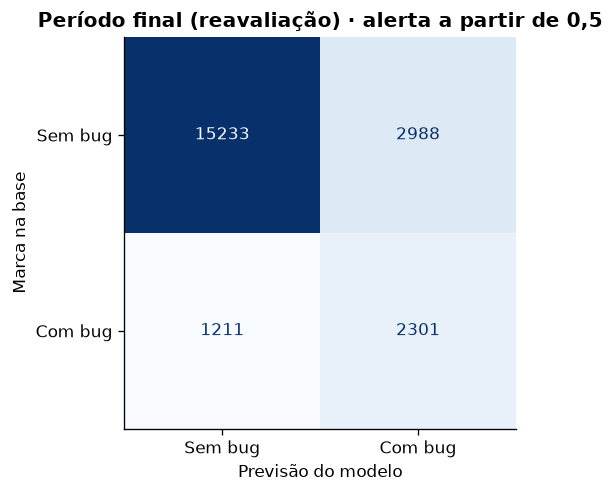

,commits,com marca de bug,alertados,acurácia do modelo,"acurácia de sempre ""sem bug"""
ano,,,,,
2017,2007,0.252,0.274,0.828,0.748
2018,9285,0.210,0.263,0.796,0.790
2019,10441,0.101,0.220,0.813,0.899


**Leitura do período final**

- **Em cada 1.000 commits:** 162 têm marca de bug. O modelo alerta 243: acerta 106 e dá 137 alarmes falsos. Deixa passar 56.
- **Métrica principal.** F1 0,523, com precision 43,5% e recall 65,5%. Na validação o F1 médio foi 0,561. O resultado caiu um pouco, mas continua na mesma faixa: o comportamento era o esperado.
- **Ordenação.** ROC-AUC 0,837: em 84% dos pares "um commit com bug e um sem", o com bug recebe o score maior.
- **Por que a acurácia (80,7%) fica abaixo de responder sempre "sem bug" (83,8%)?** Um alerta só aumenta a acurácia quando mais da metade dos alertas está certa, e aqui 43,5% estão. A tabela por ano mostra onde isso pesa: em 2019, só 10,1% dos commits têm marca de bug e o modelo continua alertando 22,0%. Parte dessa queda vem de bugs recentes que ainda não tinham sido corrigidos quando a base foi fechada, e por isso ficaram sem marca.
- **Conclusão.** O modelo serve para ordenar o que revisar primeiro. Não é um detector de bugs e o score não é uma probabilidade exata.

In [16]:
resultado = avaliar_final(config, treino, teste, divisao)
m, maioria = resultado['metricas'], resultado['referencia_majoritaria']
display(pd.DataFrame({'Modelo escolhido': m, 'Responder sempre "sem bug"': maioria}).round(4))
display(graficos.final()); plt.close('all')
(tn, fp), (fn, tp) = resultado['matriz_confusao']
n = resultado['n_teste']
final = pd.read_csv(ROOT/'resultados/previsoes_teste.csv', usecols=['data', 'buggy', 'previsao'])
final['ano'] = pd.to_datetime(final.data).dt.year
por_ano = pd.DataFrame([{'ano': ano, 'commits': len(d), 'com marca de bug': d.buggy.mean(), 'alertados': d.previsao.mean(),
                         'acurácia do modelo': (d.buggy == d.previsao).mean(), 'acurácia de sempre "sem bug"': 1 - d.buggy.mean()}
                        for ano, d in final.groupby('ano')]).set_index('ano')
display(por_ano.round(3))
pior = por_ano.index[-1]
texto(f'''**Leitura do período final**

- **Em cada 1.000 commits:** {br(1000 * (tp + fn) / n, 0)} têm marca de bug. O modelo alerta {br(1000 * (tp + fp) / n, 0)}: acerta {br(1000 * tp / n, 0)} e dá {br(1000 * fp / n, 0)} alarmes falsos. Deixa passar {br(1000 * fn / n, 0)}.
- **Métrica principal.** F1 {br(m['f1'])}, com precision {pct(m['precision'])} e recall {pct(m['recall'])}. Na validação o F1 médio foi {br(config['f1_validacao'])}. O resultado caiu um pouco, mas continua na mesma faixa: o comportamento era o esperado.
- **Ordenação.** ROC-AUC {br(m['roc_auc'])}: em {pct(m['roc_auc'], 0)} dos pares "um commit com bug e um sem", o com bug recebe o score maior.
- **Por que a acurácia ({pct(m['acuracia'])}) fica abaixo de responder sempre "sem bug" ({pct(maioria['acuracia'])})?** Um alerta só aumenta a acurácia quando mais da metade dos alertas está certa, e aqui {pct(m['precision'])} estão. A tabela por ano mostra onde isso pesa: em {pior}, só {pct(por_ano.loc[pior, 'com marca de bug'])} dos commits têm marca de bug e o modelo continua alertando {pct(por_ano.loc[pior, 'alertados'])}. Parte dessa queda vem de bugs recentes que ainda não tinham sido corrigidos quando a base foi fechada, e por isso ficaram sem marca.
- **Conclusão.** O modelo serve para ordenar o que revisar primeiro. Não é um detector de bugs e o score não é uma probabilidade exata.''')

### Teste de consistência e paridade com o aplicativo

Abaixo estão seis commits do período final, que o modelo nunca viu no treino: um de cada tipo de acerto e erro,
o mais próximo da linha de corte e um acerto com folga. Para cada um mostramos as principais entradas, a resposta
verdadeira, a previsão e o score. O teste de paridade recarrega o modelo salvo e confere que classe e score são
os mesmos que o aplicativo mostra.

In [17]:
pipeline, meta = carregar_modelo()
exemplos = pd.read_csv(ROOT/'artefatos/exemplos.csv')
mesmas = prever(pipeline, exemplos[FEATURES])
np.testing.assert_allclose(mesmas.score, exemplos.score, rtol=0, atol=1e-12)
assert np.array_equal(mesmas.previsao, exemplos.previsao)
display(exemplos[['project', 'commit_id', 'la', 'ld', 'nf', 'l_arq_mudancas_max', 'l_arq_correcoes_max', 'w_autor_commits', 'buggy', 'previsao', 'score', 'caso']])
print(f'Paridade confirmada nos {len(exemplos)} exemplos: o modelo salvo, recarregado, devolve a mesma classe e o mesmo score.')
frases = []
for e in exemplos.itertuples():
    frases.append(f"- `{e.commit_id[:8]}` ({e.caso.lower()}, score {br(e.score, 4)}): {e.la} linhas adicionadas e {e.ld} removidas em {e.nf} arquivo(s). "
                  f"Histórico dos arquivos: até {e.l_arq_mudancas_max:.0f} mudanças anteriores e até {e.l_arq_correcoes_max:.0f} mensagens de correção.")
texto('**Leitura dos casos**\n\n' + '\n'.join(frases) + '''

O padrão é coerente com o que o modelo aprendeu: o score sobe quando a alteração é grande e mexe em arquivos
com muito histórico. Os erros também fazem sentido: um falso negativo é um commit com bug em arquivos de pouco
histórico, e um falso positivo é um commit grande que não deu problema. São exemplos para entender o modelo,
não uma amostra para medir desempenho.''')

,project,commit_id,la,ld,nf,l_arq_mudancas_max,l_arq_correcoes_max,w_autor_commits,buggy,previsao,score,caso
0,apache/camel,b584b3d304127dcaacb6ee12972fded1ae5bdd2d,486,1,8,20,1,7,0,0,0.452484,Verdadeiro negativo
1,apache/flink,c3235c395f7bb69b482b85c6832d427100130ca3,461,399,26,25,7,103,0,1,0.565872,Falso positivo
2,apache/kafka,10cd98cc894b88c5d1e24fc54c66361ad9914df2,145,127,7,198,18,60,1,1,0.799059,Verdadeiro positivo
3,apache/camel,2712739524cc9c263b2013fbd19a69a6404620e1,117,332,10,2,1,4,1,0,0.153497,Falso negativo
4,apache/kafka,93e03414f72c24854abaa6925149196580cfc691,563,147,12,7,3,16,0,0,0.499935,Verdadeiro negativo
5,apache/ignite,85261a341936547693aaed2105dc504fda2a9bf7,2,0,1,27,0,39,0,0,0.037780,Verdadeiro negativo


Paridade confirmada nos 6 exemplos: o modelo salvo, recarregado, devolve a mesma classe e o mesmo score.


**Leitura dos casos**

- `b584b3d3` (verdadeiro negativo, score 0,4525): 486 linhas adicionadas e 1 removidas em 8 arquivo(s). Histórico dos arquivos: até 20 mudanças anteriores e até 1 mensagens de correção.
- `c3235c39` (falso positivo, score 0,5659): 461 linhas adicionadas e 399 removidas em 26 arquivo(s). Histórico dos arquivos: até 25 mudanças anteriores e até 7 mensagens de correção.
- `10cd98cc` (verdadeiro positivo, score 0,7991): 145 linhas adicionadas e 127 removidas em 7 arquivo(s). Histórico dos arquivos: até 198 mudanças anteriores e até 18 mensagens de correção.
- `27127395` (falso negativo, score 0,1535): 117 linhas adicionadas e 332 removidas em 10 arquivo(s). Histórico dos arquivos: até 2 mudanças anteriores e até 1 mensagens de correção.
- `93e03414` (verdadeiro negativo, score 0,4999): 563 linhas adicionadas e 147 removidas em 12 arquivo(s). Histórico dos arquivos: até 7 mudanças anteriores e até 3 mensagens de correção.
- `85261a34` (verdadeiro negativo, score 0,0378): 2 linhas adicionadas e 0 removidas em 1 arquivo(s). Histórico dos arquivos: até 27 mudanças anteriores e até 0 mensagens de correção.

O padrão é coerente com o que o modelo aprendeu: o score sobe quando a alteração é grande e mexe em arquivos
com muito histórico. Os erros também fazem sentido: um falso negativo é um commit com bug em arquivos de pouco
histórico, e um falso positivo é um commit grande que não deu problema. São exemplos para entender o modelo,
não uma amostra para medir desempenho.

In [18]:
print('GitHub:', URL_GITHUB or 'pendente de publicação')
print('Streamlit:', URL_STREAMLIT or 'pendente de publicação')

GitHub: https://github.com/DaviJDuarte/DataScience-CP5
Streamlit: pendente de publicação


### Aplicativo Streamlit

`streamlit run app.py` abre o aplicativo. Ele carrega o mesmo modelo salvo e usa a mesma função de previsão deste notebook.

- **Demonstração local:** os seis exemplos acima, sem internet. A tela mostra o score, a classe, a faixa de risco, as 48 entradas e a confirmação de paridade.
- **GitHub:** informa-se um repositório público e escolhe-se um commit. Para calcular o histórico, o aplicativo precisa de uma cópia do histórico do repositório, que pode ser baixada pela própria tela. Isso pode demorar em repositórios grandes. O código do repositório nunca é executado.
- **O que é recusado:** merges, commits com arquivos binários ou submódulos, histórico incompleto e contagens que não batem com as do GitHub. Nesses casos aparece uma mensagem explicando o motivo.

Os testes automáticos estão em `testar_projeto.py` (divisão, modelo salvo, exemplos, aplicativo sem internet)
e `testar_extracao.py` (o histórico nunca usa informação do futuro).

### Limitações

- As marcas de bug vêm de um método automático (SZZ) e têm erros. Bugs recentes ainda sem correção ficam sem marca.
- O período final já era conhecido da primeira versão; o resultado final é uma reavaliação.
- Os projetos são da Apache e em Java. Não testamos em projetos de outro tipo.
- Regras simples decidem o que é arquivo de teste e o que é mensagem de correção; elas erram em alguns casos.
- O limiar ficou em 0,5 e o score não foi calibrado. Mudar isso pediria uma nova validação definida antes.

### Conclusão

O histórico dos arquivos e dos autores acrescenta informação além do tamanho do commit. Os três algoritmos chegam
a resultados parecidos; o LightGBM ajustado com Optuna foi o escolhido pela regra definida antes. O modelo é útil
para ordenar commits para revisão e está longe de acertar tudo, o que mostramos junto com os erros.

### Referências

- Keshavarz, H.; Nagappan, M. *ApacheJIT: A Large Dataset for Just-In-Time Defect Prediction*. [Zenodo](https://zenodo.org/records/5907847) e [artigo](https://arxiv.org/abs/2203.00101).
- Breiman (2001), *Random Forests*; Chen e Guestrin (2016), *XGBoost*; Ke et al. (2017), *LightGBM*; Akiba et al. (2019), *Optuna*.
- Enunciado do Checkpoint 5 e notebooks das aulas 18, 19 e 20 da disciplina.